# Kutch Seismic EDA

Exploratory analysis of the Kutch earthquake catalog (1990–present, M≥2.0).
Primary source: USGS ComCat. Supplementary: ISC FDSN (run `src/fetch_isc.py` to add).

**Run order**: `fetch_usgs.py` → `fetch_isc.py` (optional) → `preprocess.py` → this notebook.

---
## Contents
1. Data Overview
2. Magnitude Distribution
3. Depth Distribution
4. Temporal Trends
5. Spatial Map
6. Gutenberg-Richter Analysis (MLE, MAXC)
6b. Dual Mc: MAXC vs Goodness-of-Fit (GFT 90%)
7. Bhuj 2001 Aftershock Sequence — Omori-Utsu Decay
8. Rolling b-value Through Time
9. Omori-Utsu Verification: log(time) vs log(rate)

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.optimize import curve_fit
import folium

# ---- Paths ----
DATA_PATH = Path('../data/processed/kutch_clean.csv')
OUT_DIR   = Path('../outputs')
OUT_DIR.mkdir(exist_ok=True)

# ---- Plot style ----
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150,
                     'figure.figsize': (10, 5)})

# ---- Bhuj mainshock constants ----
BHUJ_DATE = pd.Timestamp('2001-01-26', tz='UTC')
BHUJ_LAT, BHUJ_LON = 23.419, 70.232
BHUJ_MAG = 7.7

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load cleaned catalog
df = pd.read_csv(DATA_PATH)

# Explicit UTC-aware datetime parsing (works across pandas 1.x and 2.x)
for col in ['time_utc', 'updated_utc']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], utc=True, errors='coerce')

# Ensure categorical depth_cat is ordered correctly
depth_order = pd.CategoricalDtype(['shallow', 'intermediate', 'deep'], ordered=True)
df['depth_cat'] = df['depth_cat'].astype(depth_order)

print(f'Loaded {len(df):,} events.')
if 'source' in df.columns:
    print('Source breakdown:')
    print(df.source.value_counts().to_string())
print(f'Date range: {df.time_utc.min().date()} -> {df.time_utc.max().date()}')
print(f'Magnitude range: {df.magnitude.min():.1f} - {df.magnitude.max():.1f}')

Loaded 1,311 events.
Source breakdown:
source
isc     1143
usgs     168
Date range: 1991-01-20 -> 2025-12-25
Magnitude range: 2.0 - 7.7


---
## 1  Data Overview

In [3]:
print('=== Shape ===')
print(f'Rows: {len(df):,}   Columns: {df.shape[1]}')

print('\n=== Descriptive statistics (numeric) ===')
display(df[['magnitude','depth_km','latitude','longitude']].describe().round(3))

print('\n=== Missing values ===')
missing = df.isnull().sum()
display(missing[missing > 0])

=== Shape ===
Rows: 1,311   Columns: 30

=== Descriptive statistics (numeric) ===


,magnitude,depth_km,latitude,longitude
count,1311.000,1311.000,1311.000,1311.000
mean,3.372,15.999,23.453,70.284
std,0.675,8.878,0.235,0.294
min,2.000,0.000,22.117,68.013
25%,3.000,10.000,23.357,70.170
50%,3.300,15.000,23.450,70.302
75%,3.795,20.000,23.546,70.413
max,7.700,63.700,24.500,71.462



=== Missing values ===


type              1143
status            1143
net               1143
nst               1155
dmin              1301
rms               1143
gap               1275
url               1143
updated_utc       1143
isc_event_id       168
author             168
catalog            168
contributor        168
contributor_id     168
mag_author         168
event_type         168
dtype: int64

In [4]:
# Flag the Bhuj mainshock row
bhuj_row = df[df.magnitude == df.magnitude.max()].iloc[0]
print('Largest event in catalog:')
print(f"  ID        : {bhuj_row['id']}")
print(f"  Time (UTC): {bhuj_row['time_utc']}")
print(f"  Magnitude : {bhuj_row['magnitude']} ({bhuj_row['mag_type']})")
print(f"  Location  : {bhuj_row['latitude']:.3f}N, {bhuj_row['longitude']:.3f}E")
print(f"  Depth     : {bhuj_row['depth_km']:.1f} km  [{bhuj_row['depth_cat']}]")

Largest event in catalog:
  ID        : usp000a8ds
  Time (UTC): 2001-01-26 03:16:40.500000+00:00
  Magnitude : 7.7 (mwc)
  Location  : 23.419N, 70.232E
  Depth     : 16.0 km  [shallow]


---
## 2  Magnitude Distribution

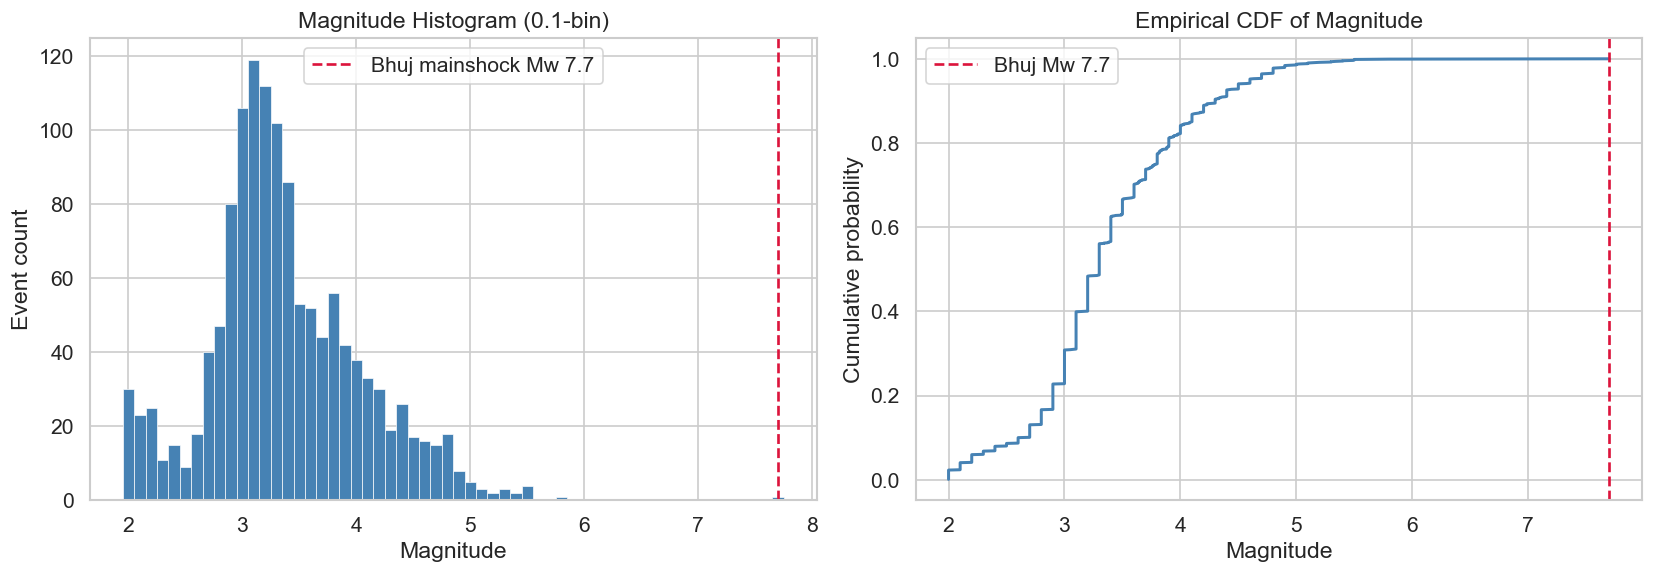

Saved -> outputs/magnitude_distribution.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram ---
ax = axes[0]
bins = np.arange(df.magnitude.min() - 0.05, df.magnitude.max() + 0.15, 0.1)
ax.hist(df.magnitude, bins=bins, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(BHUJ_MAG, color='crimson', linestyle='--', linewidth=1.6,
           label=f'Bhuj mainshock Mw {BHUJ_MAG}')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Event count')
ax.set_title('Magnitude Histogram (0.1-bin)')
ax.legend()

# --- Empirical CDF ---
ax = axes[1]
sorted_m = np.sort(df.magnitude)
cdf = np.arange(1, len(sorted_m) + 1) / len(sorted_m)
ax.plot(sorted_m, cdf, color='steelblue', linewidth=1.8)
ax.axvline(BHUJ_MAG, color='crimson', linestyle='--', linewidth=1.6,
           label=f'Bhuj Mw {BHUJ_MAG}')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Cumulative probability')
ax.set_title('Empirical CDF of Magnitude')
ax.legend()

fig.tight_layout()
fig.savefig(OUT_DIR / 'magnitude_distribution.png')
plt.show()
print('Saved -> outputs/magnitude_distribution.png')

---
## 3  Depth Distribution

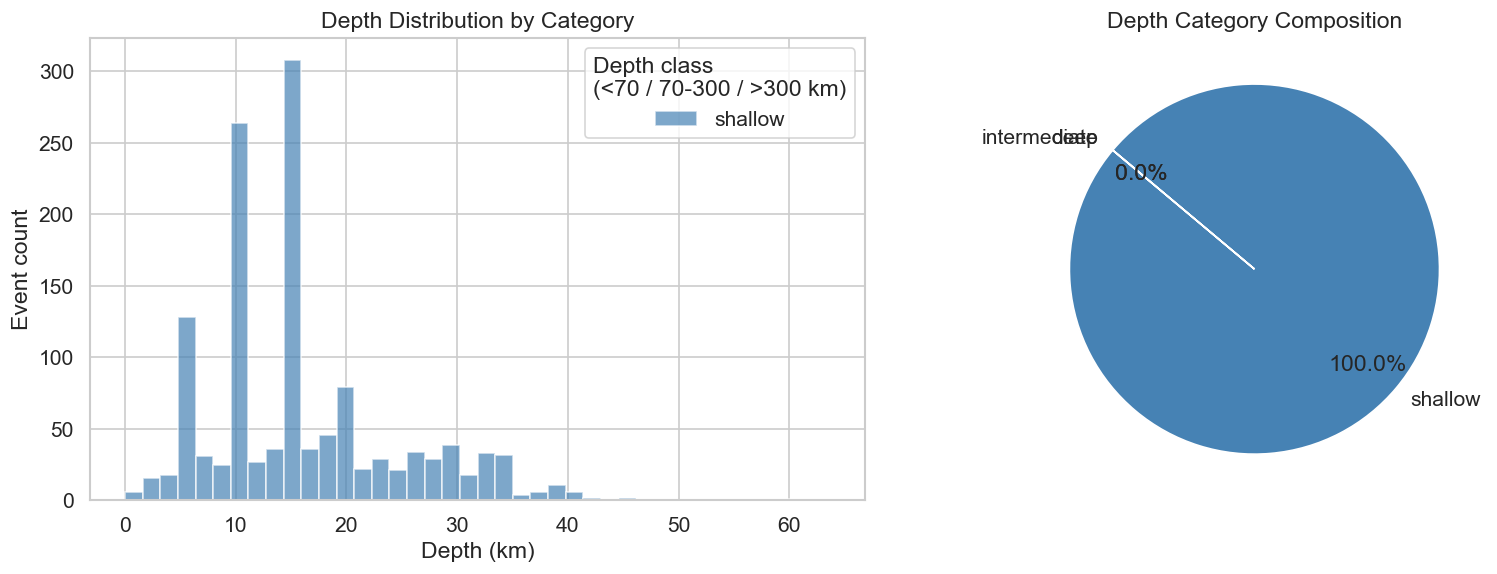

Saved -> outputs/depth_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

CAT_COLORS = {'shallow': 'steelblue', 'intermediate': 'darkorange', 'deep': 'crimson'}

# --- Histogram coloured by depth_cat ---
ax = axes[0]
for cat in ['shallow', 'intermediate', 'deep']:
    subset = df[df.depth_cat == cat]['depth_km']
    if len(subset):
        ax.hist(subset, bins=40, alpha=0.7, label=cat, color=CAT_COLORS[cat])
ax.set_xlabel('Depth (km)')
ax.set_ylabel('Event count')
ax.set_title('Depth Distribution by Category')
ax.legend(title='Depth class\n(<70 / 70-300 / >300 km)')

# --- Pie chart of depth category proportion ---
ax = axes[1]
cat_counts = df['depth_cat'].value_counts()[['shallow', 'intermediate', 'deep']]
wedge_colors = [CAT_COLORS[c] for c in cat_counts.index]
ax.pie(cat_counts.values, labels=cat_counts.index, colors=wedge_colors,
       autopct='%1.1f%%', startangle=140, pctdistance=0.8)
ax.set_title('Depth Category Composition')

fig.tight_layout()
fig.savefig(OUT_DIR / 'depth_distribution.png')
plt.show()
print('Saved -> outputs/depth_distribution.png')

---
## 4  Temporal Trends

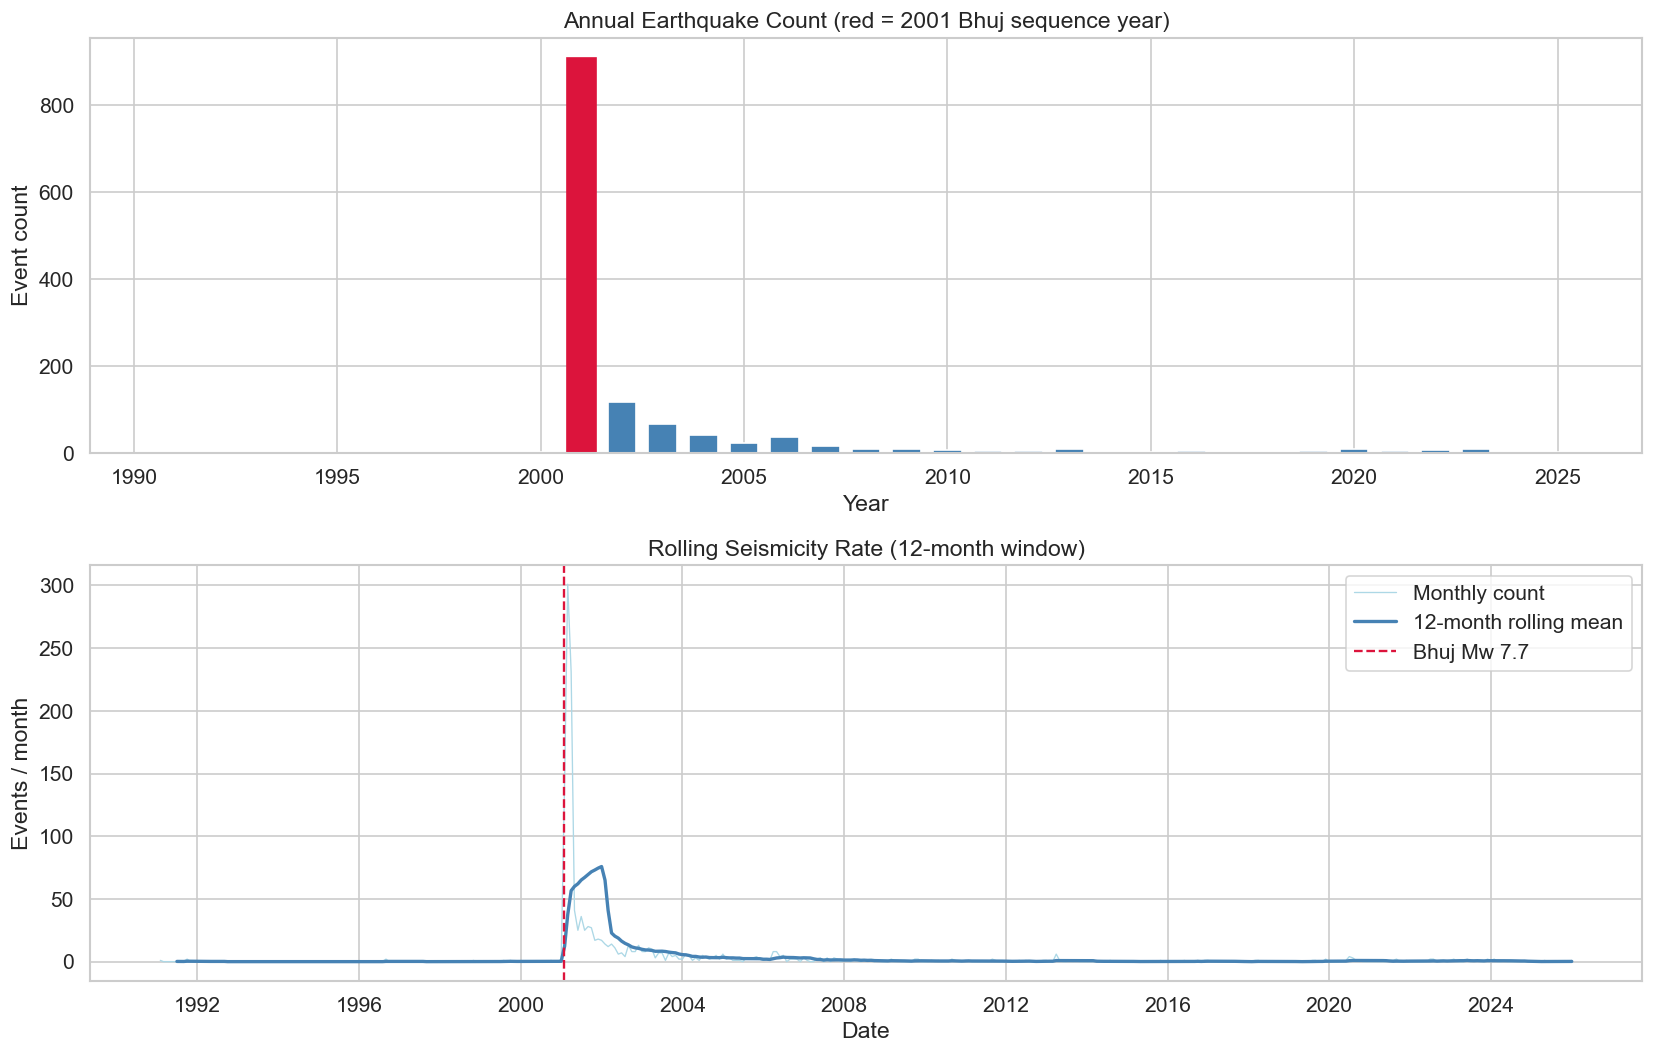

Saved -> outputs/temporal_trends.png


In [7]:
annual = df.groupby('year').size().rename('count').reset_index()

# 12-month rolling rate (events per month)
monthly = (df.set_index('time_utc')
             .resample('ME')
             .size()
             .rename('monthly_count'))
rolling_12m = monthly.rolling(12, min_periods=6).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# --- Annual bar chart ---
ax = axes[0]
bars = ax.bar(annual.year, annual['count'], color='steelblue', width=0.7)
bhuj_yr_idx = annual[annual.year == 2001].index
if len(bhuj_yr_idx):
    bars[bhuj_yr_idx[0]].set_color('crimson')
ax.set_xlabel('Year')
ax.set_ylabel('Event count')
ax.set_title('Annual Earthquake Count (red = 2001 Bhuj sequence year)')
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))

# --- 12-month rolling seismicity rate ---
ax = axes[1]
ax.plot(monthly.index, monthly.values, color='lightblue', linewidth=0.8, label='Monthly count')
ax.plot(rolling_12m.index, rolling_12m.values, color='steelblue', linewidth=2,
        label='12-month rolling mean')
ax.axvline(BHUJ_DATE, color='crimson', linestyle='--', linewidth=1.4, label='Bhuj Mw 7.7')
ax.set_xlabel('Date')
ax.set_ylabel('Events / month')
ax.set_title('Rolling Seismicity Rate (12-month window)')
ax.legend()

fig.tight_layout()
fig.savefig(OUT_DIR / 'temporal_trends.png')
plt.show()
print('Saved -> outputs/temporal_trends.png')

---
## 5  Spatial Map

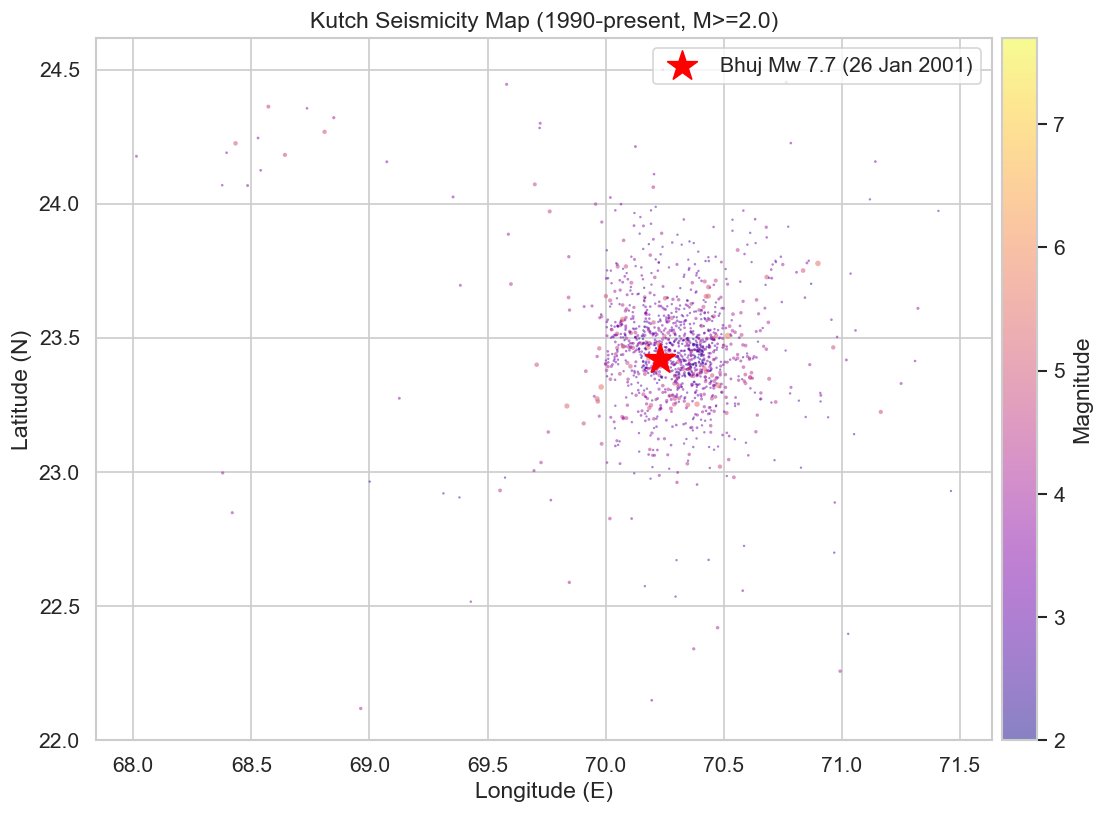

Saved -> outputs/spatial_map.png


In [8]:
# ---- Matplotlib scatter (static export) ----
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(
    df.longitude, df.latitude,
    c=df.magnitude, cmap='plasma',
    s=np.clip(2 ** (df.magnitude - 2), 2, 200),
    alpha=0.5, linewidths=0.2, edgecolors='none'
)
ax.scatter(BHUJ_LON, BHUJ_LAT, s=350, marker='*', color='red',
           zorder=5, label=f'Bhuj Mw {BHUJ_MAG} (26 Jan 2001)')

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label('Magnitude')
ax.set_xlabel('Longitude (E)')
ax.set_ylabel('Latitude (N)')
ax.set_title('Kutch Seismicity Map (1990-present, M>=2.0)')
ax.legend(loc='upper right')

fig.tight_layout()
fig.savefig(OUT_DIR / 'spatial_map.png')
plt.show()
print('Saved -> outputs/spatial_map.png')

In [9]:
# ---- Folium interactive map ----
from folium.plugins import HeatMap

fmap = folium.Map(location=[23.2, 70.0], zoom_start=8, tiles='CartoDB positron')

heat_data = df[['latitude', 'longitude', 'magnitude']].dropna().values.tolist()
HeatMap(heat_data, radius=8, blur=12, max_zoom=10).add_to(fmap)

for _, row in df[df.magnitude >= 5.0].iterrows():
    folium.CircleMarker(
        location=[row.latitude, row.longitude],
        radius=max(3, (row.magnitude - 4) * 4),
        color='orange', fill=True, fill_opacity=0.6,
        popup=f"M{row.magnitude:.1f} | {str(row.time_utc)[:10]} | {row.depth_km:.0f} km deep"
    ).add_to(fmap)

# Explicit Bhuj mainshock marker — do NOT rely on heatmap alone
folium.Marker(
    location=[BHUJ_LAT, BHUJ_LON],
    popup=folium.Popup(
        f'<b>Bhuj Earthquake</b><br>Mw {BHUJ_MAG} | 26 Jan 2001<br>'
        f'{BHUJ_LAT}N, {BHUJ_LON}E',
        max_width=220
    ),
    tooltip='Bhuj Mw 7.7 (26 Jan 2001)',
    icon=folium.Icon(color='red', icon='star', prefix='fa')
).add_to(fmap)

map_path = OUT_DIR / 'kutch_interactive_map.html'
fmap.save(str(map_path))
print(f'Interactive map saved -> {map_path}')
fmap

Interactive map saved -> ..\outputs\kutch_interactive_map.html


---
## 6  Gutenberg-Richter Analysis (MLE)

The **Gutenberg-Richter relation** is log10(N) = a - b*M.

### b-value estimation — MLE (Aki 1965)
**b = log10(e) / (mean_M - Mc)**

> **Why MLE, not least-squares?** The log-N scatter is heteroscedastic and the upper tail is sparse. MLE is statistically consistent (Utsu 1965, Marzocchi & Sandri 2003).

### Mc — Maximum Curvature (MAXC)
Mc = magnitude bin at the peak of the incremental frequency-magnitude histogram. Known to underestimate Mc by ~0.2 units; compare with GFT in §6b.

In [10]:
def compute_mc_maxc(magnitudes: np.ndarray, bin_width: float = 0.1) -> float:
    """Maximum curvature method: Mc = magnitude of peak frequency bin."""
    bins = np.arange(magnitudes.min(), magnitudes.max() + bin_width, bin_width)
    counts, edges = np.histogram(magnitudes, bins=bins)
    centers = edges[:-1] + bin_width / 2
    return round(centers[counts.argmax()], 1)


def bvalue_mle(magnitudes: np.ndarray, mc: float) -> tuple:
    """
    Maximum likelihood b-value (Aki 1965):
        b  = log10(e) / (mean_M - Mc)
        sb = b / sqrt(N)   (standard error)

    Preferred over least-squares — see Marzocchi & Sandri 2003.
    """
    above_mc = magnitudes[magnitudes >= mc]
    n = len(above_mc)
    b = np.log10(np.e) / (above_mc.mean() - mc)
    sigma_b = b / np.sqrt(n)
    return b, sigma_b


mags = df['magnitude'].dropna().values
Mc   = compute_mc_maxc(mags)
b, sb = bvalue_mle(mags, Mc)
above = mags[mags >= Mc]

print(f'MAXC Mc        = {Mc:.1f}')
print(f'Events >= Mc   = {len(above):,}')
print(f'b-value (MLE)  = {b:.3f} +/- {sb:.3f}')
print()
if 0.9 <= b <= 1.05:
    print('b-value is within the expected range for Kutch (0.9-1.05, published literature).')
else:
    print('b-value is outside the typical Kutch range (0.9-1.05).')
    print('  -> Check Mc estimation first before assuming a data problem.')

MAXC Mc        = 3.1
Events >= Mc   = 905
b-value (MLE)  = 0.749 +/- 0.025

b-value is outside the typical Kutch range (0.9-1.05).
  -> Check Mc estimation first before assuming a data problem.


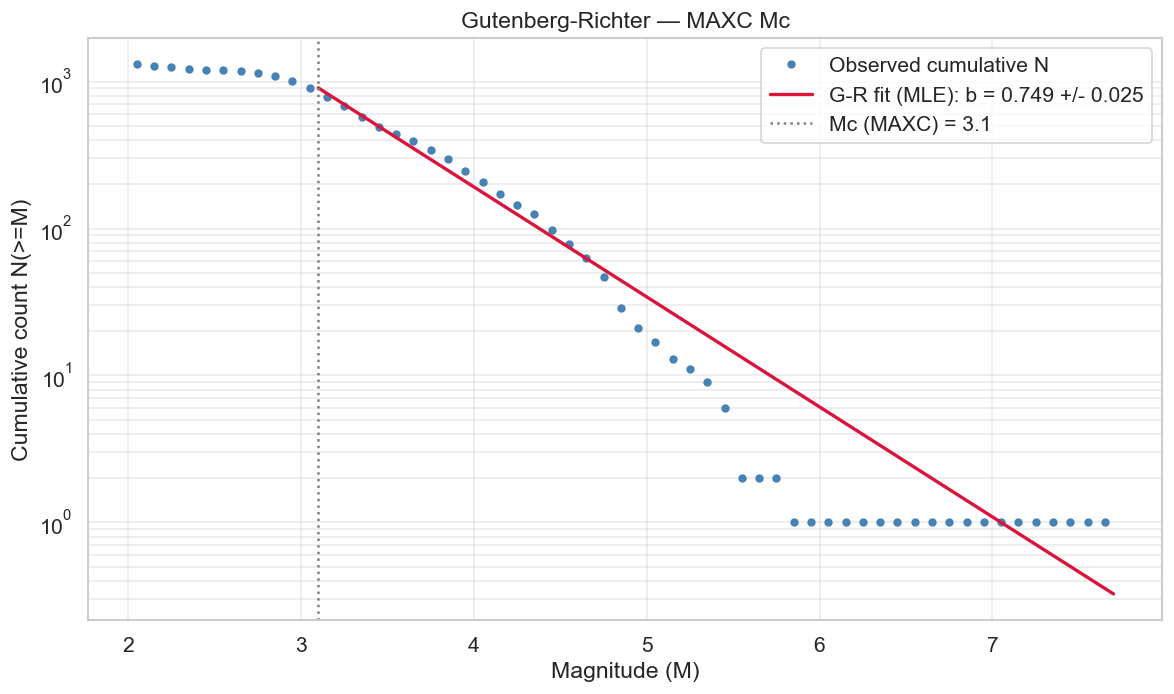

Saved -> outputs/gutenberg_richter.png


In [11]:
# ---- Gutenberg-Richter Plot (MAXC Mc) ----
bin_width = 0.1
bins = np.arange(mags.min(), mags.max() + 2 * bin_width, bin_width)
counts, edges = np.histogram(mags, bins=bins)
centers = edges[:-1] + bin_width / 2
cum_counts = np.cumsum(counts[::-1])[::-1]
nonzero = cum_counts > 0

fig, ax = plt.subplots(figsize=(10, 6))
ax.semilogy(centers[nonzero], cum_counts[nonzero], 'o', color='steelblue',
            markersize=4, label='Observed cumulative N')

m_fit = np.linspace(Mc, mags.max(), 200)
a_val = np.log10(len(above))
n_fit = 10 ** (a_val - b * (m_fit - Mc))
ax.semilogy(m_fit, n_fit, '-', color='crimson', linewidth=2,
            label=f'G-R fit (MLE): b = {b:.3f} +/- {sb:.3f}')
ax.axvline(Mc, color='gray', linestyle=':', linewidth=1.5, label=f'Mc (MAXC) = {Mc}')

ax.set_xlabel('Magnitude (M)')
ax.set_ylabel('Cumulative count N(>=M)')
ax.set_title('Gutenberg-Richter — MAXC Mc')
ax.legend()
ax.grid(True, which='both', alpha=0.4)

fig.tight_layout()
fig.savefig(OUT_DIR / 'gutenberg_richter.png')
plt.show()
print('Saved -> outputs/gutenberg_richter.png')

---
## 6b  Dual Mc Estimation: MAXC vs Goodness-of-Fit (GFT 90%)

| Method | Description | Known bias |
|--------|-------------|------------|
| **MAXC** | Mc = peak of FMD histogram | Underestimates by ~0.2 units |
| **GFT (90%)** | Lowest M where FMD fits G-R within 10% absolute error | Conservative; robust for sparse catalogs |

> **Stability check**: if MAXC and GFT90 agree within 0.2 units -> stable Mc. If gap > 0.3 -> treat b-value cautiously; likely catalog incompleteness effect.

In [12]:
def gft_mc(magnitudes: np.ndarray, bin_width: float = 0.1,
           threshold: float = 0.10) -> tuple:
    """
    Goodness-of-Fit Test for Mc (Wiemer & Wyss 2000).

    For each candidate Mc, fit G-R using MLE b, then compute the absolute
    relative misfit R between observed and synthetic cumulative counts.
    Mc_GFT = lowest candidate where R <= threshold (i.e. 90% fit).
    If no candidate satisfies the criterion, returns the minimum-R candidate.

    Returns: (Mc_gft, candidates_array, R_array)
    """
    bins = np.arange(magnitudes.min(), magnitudes.max() + bin_width, bin_width)
    centers = bins[:-1] + bin_width / 2
    obs_counts, _ = np.histogram(magnitudes, bins=bins)
    obs_cum = np.cumsum(obs_counts[::-1])[::-1]  # N >= M

    candidates = centers[obs_cum >= 20]   # need >= 20 events above Mc
    if len(candidates) == 0:
        candidates = centers[obs_cum >= 5]

    R_values = []
    for mc in candidates:
        above = magnitudes[magnitudes >= mc]
        if len(above) < 5:
            R_values.append(np.nan)
            continue
        b_mle = np.log10(np.e) / (above.mean() - mc)
        a_val  = np.log10(len(above))
        mc_idx = np.searchsorted(centers, mc)
        syn_cum = 10 ** (a_val - b_mle * (centers[mc_idx:] - mc))
        obs_seg = obs_cum[mc_idx:]
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            R = np.sum(np.abs(obs_seg - syn_cum)) / np.sum(obs_seg)
        R_values.append(R)

    R_arr   = np.array(R_values)
    passing = candidates[R_arr <= threshold]
    mc_gft  = passing[0] if len(passing) else candidates[np.nanargmin(R_arr)]
    return round(mc_gft, 1), candidates, R_arr


# --- Compute both ---
Mc_maxc = compute_mc_maxc(mags)
b_maxc, sb_maxc = bvalue_mle(mags, Mc_maxc)

Mc_gft, gft_candidates, gft_R = gft_mc(mags)
b_gft, sb_gft = bvalue_mle(mags, Mc_gft)

print(f'MAXC  Mc = {Mc_maxc:.1f}  =>  b = {b_maxc:.3f} +/- {sb_maxc:.3f}')
print(f'GFT90 Mc = {Mc_gft:.1f}  =>  b = {b_gft:.3f} +/- {sb_gft:.3f}')

delta_mc = abs(Mc_maxc - Mc_gft)
if delta_mc <= 0.2:
    print(f'\nMc estimates agree within 0.2 (delta={delta_mc:.1f}) -> stable estimate.')
    Mc, b, sb = Mc_gft, b_gft, sb_gft   # prefer GFT (more conservative)
else:
    print(f'\nMc estimates diverge by {delta_mc:.1f} -> interpret b-value cautiously.')
    Mc, b, sb = Mc_gft, b_gft, sb_gft

print(f'\nFinal chosen Mc = {Mc}  |  b = {b:.3f} +/- {sb:.3f}')
if 0.9 <= b <= 1.05:
    print('b-value within expected Kutch range (0.9-1.05).')
else:
    print('b-value outside expected Kutch range. Check Mc first.')

MAXC  Mc = 3.1  =>  b = 0.749 +/- 0.025
GFT90 Mc = 3.0  =>  b = 0.715 +/- 0.022

Mc estimates agree within 0.2 (delta=0.1) -> stable estimate.

Final chosen Mc = 3.0  |  b = 0.715 +/- 0.022
b-value outside expected Kutch range. Check Mc first.


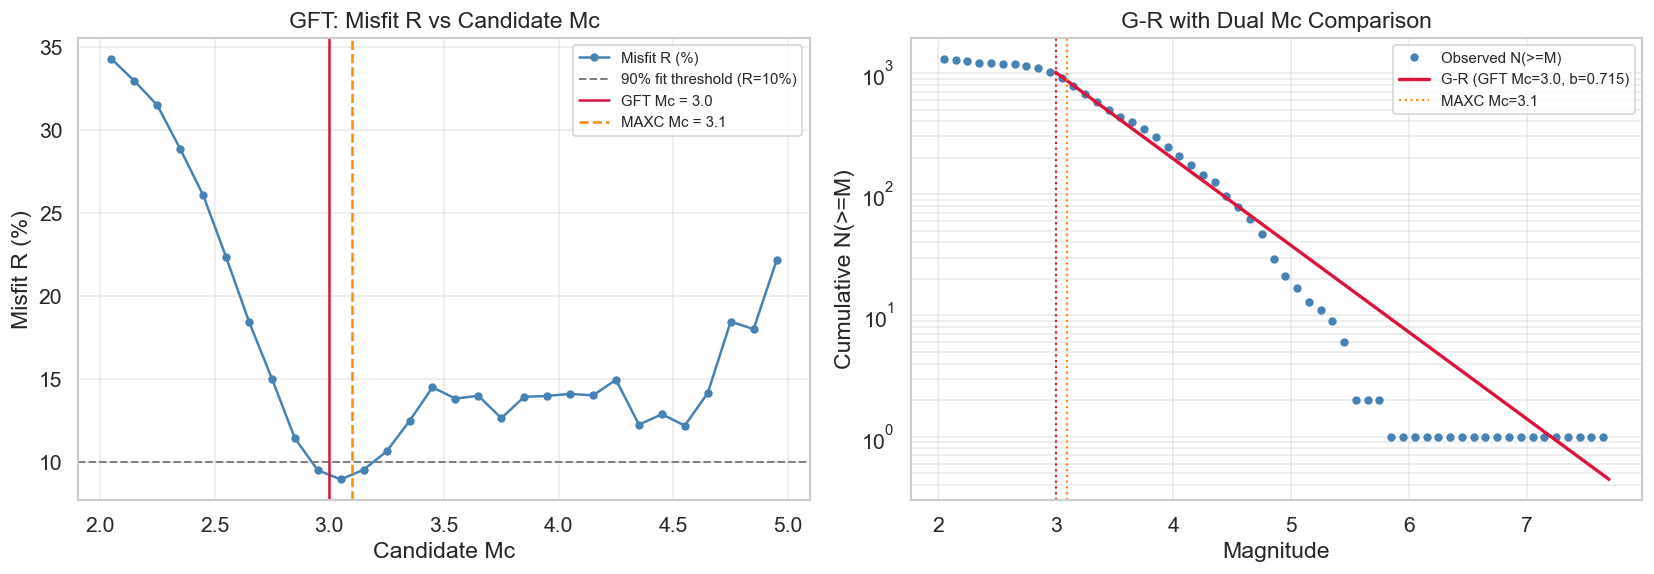

Saved -> outputs/gutenberg_richter_dual_mc.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- R-curve ---
ax = axes[0]
valid = ~np.isnan(gft_R)
ax.plot(gft_candidates[valid], gft_R[valid] * 100, 'o-', color='steelblue',
        markersize=4, linewidth=1.5, label='Misfit R (%)')
ax.axhline(10, color='gray', linestyle='--', linewidth=1.2, label='90% fit threshold (R=10%)')
ax.axvline(Mc_gft, color='crimson', linestyle='-', linewidth=1.5,
           label=f'GFT Mc = {Mc_gft}')
ax.axvline(Mc_maxc, color='darkorange', linestyle='--', linewidth=1.5,
           label=f'MAXC Mc = {Mc_maxc}')
ax.set_xlabel('Candidate Mc')
ax.set_ylabel('Misfit R (%)')
ax.set_title('GFT: Misfit R vs Candidate Mc')
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

# --- G-R plot with dual Mc lines ---
ax = axes[1]
_bw = 0.1
_bins = np.arange(mags.min(), mags.max() + 2 * _bw, _bw)
_c, _e = np.histogram(mags, bins=_bins)[0], np.histogram(mags, bins=_bins)[1]
_ctrs = _e[:-1] + _bw / 2
_cum  = np.cumsum(_c[::-1])[::-1]
nz    = _cum > 0
ax.semilogy(_ctrs[nz], _cum[nz], 'o', color='steelblue', markersize=4, label='Observed N(>=M)')

above_chosen = mags[mags >= Mc]
m_fit = np.linspace(Mc, mags.max(), 200)
n_fit = 10 ** (np.log10(len(above_chosen)) - b * (m_fit - Mc))
ax.semilogy(m_fit, n_fit, '-', color='crimson', linewidth=2,
            label=f'G-R (GFT Mc={Mc}, b={b:.3f})')
ax.axvline(Mc, color='crimson', linestyle=':', linewidth=1.3)
ax.axvline(Mc_maxc, color='darkorange', linestyle=':', linewidth=1.3,
           label=f'MAXC Mc={Mc_maxc}')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Cumulative N(>=M)')
ax.set_title('G-R with Dual Mc Comparison')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.4)

fig.tight_layout()
fig.savefig(OUT_DIR / 'gutenberg_richter_dual_mc.png')
plt.show()
print('Saved -> outputs/gutenberg_richter_dual_mc.png')

---
## 7  Bhuj 2001 Aftershock Sequence — Omori-Utsu Decay

lambda(t) = K / (t + c)^p

> **Detection incompleteness**: First ~24 h after a large event are affected by seismometer saturation. Fit starts from **day 2** (27 Jan 2001) — standard practice.

In [14]:
seq_start = pd.Timestamp('2001-01-26', tz='UTC')
seq_end   = pd.Timestamp('2002-12-31 23:59:59', tz='UTC')

seq = df[(df.time_utc >= seq_start) & (df.time_utc <= seq_end)].copy()
seq['days_after'] = (seq.time_utc - seq_start).dt.total_seconds() / 86_400

print(f'Total events in sequence window: {len(seq):,}')
print(f'  On mainshock day (t<1) : {(seq.days_after < 1).sum()}')
print(f'  From day 2 onward      : {(seq.days_after >= 1).sum()}')

Total events in sequence window: 1,028
  On mainshock day (t<1) : 53
  From day 2 onward      : 975


In [15]:
fit_start_day = 1
fit_seq = seq[seq.days_after >= fit_start_day].copy()

max_day  = int(fit_seq.days_after.max()) + 1
day_bins = np.arange(fit_start_day, max_day + 1)
daily_counts, _ = np.histogram(fit_seq.days_after, bins=day_bins)
day_centers = day_bins[:-1] + 0.5

def omori_utsu(t, K, c, p):
    """Omori-Utsu aftershock rate: lambda(t) = K / (t + c)^p"""
    return K / (t + c) ** p

nonzero_mask = daily_counts > 0
t_fit = day_centers[nonzero_mask]
n_fit = daily_counts[nonzero_mask].astype(float)

try:
    popt, pcov = curve_fit(
        omori_utsu, t_fit, n_fit,
        p0=[100, 0.1, 1.0],
        bounds=([0, 0, 0], [1e6, 10, 3]),
        maxfev=10_000
    )
    K_fit, c_fit, p_fit = popt
    perr = np.sqrt(np.diag(pcov))
    print('Omori-Utsu parameters:')
    print(f'  K = {K_fit:.2f} +/- {perr[0]:.2f}')
    print(f'  c = {c_fit:.4f} +/- {perr[1]:.4f} days')
    print(f'  p = {p_fit:.3f} +/- {perr[2]:.3f}')
    fit_ok = True
except RuntimeError as exc:
    print(f'Curve fit did not converge: {exc}')
    fit_ok = False

Omori-Utsu parameters:
  K = 170.82 +/- 108.32
  c = 10.0000 +/- 5.2997 days
  p = 0.830 +/- 0.134


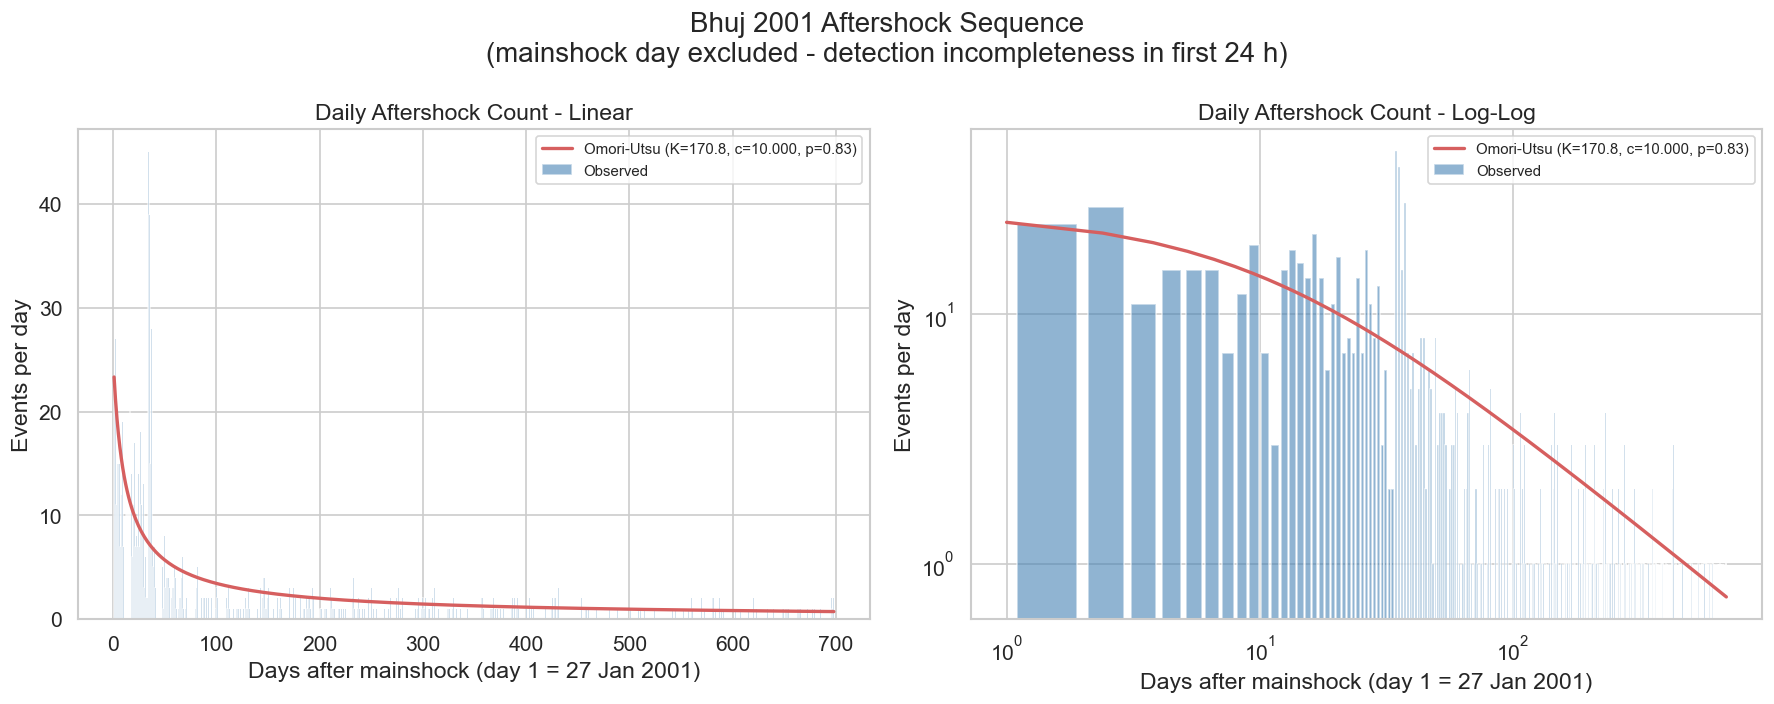

Saved -> outputs/omori_utsu_decay.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, xscale, yscale, title in [
    (axes[0], 'linear', 'linear', 'Daily Aftershock Count - Linear'),
    (axes[1], 'log',    'log',    'Daily Aftershock Count - Log-Log'),
]:
    ax.bar(day_centers, daily_counts, width=0.8, color='steelblue', alpha=0.6, label='Observed')
    if fit_ok:
        t_smooth = np.linspace(fit_start_day, max_day, 500)
        ax.plot(t_smooth, omori_utsu(t_smooth, *popt), 'r-', linewidth=2,
                label=f'Omori-Utsu (K={K_fit:.1f}, c={c_fit:.3f}, p={p_fit:.2f})')
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)
    ax.set_xlabel('Days after mainshock (day 1 = 27 Jan 2001)')
    ax.set_ylabel('Events per day')
    ax.set_title(title)
    ax.legend(fontsize=9)

fig.suptitle('Bhuj 2001 Aftershock Sequence\n'
             '(mainshock day excluded - detection incompleteness in first 24 h)')
fig.tight_layout()
fig.savefig(OUT_DIR / 'omori_utsu_decay.png')
plt.show()
print('Saved -> outputs/omori_utsu_decay.png')

---
## 8  Rolling b-value Through Time

A time-varying b-value reveals stress-state changes. A drop in b before large events has been proposed as a precursor signal in some regions.

Computed in a **sliding window of 50 events** (minimum for stable MLE).

> With ~170 USGS events the windows will be coarse. Adding ISC data (M2-3.9) will sharpen this significantly.

In [17]:
WINDOW = 50   # events per window
STEP   = 10   # slide step

df_sorted  = df.dropna(subset=['magnitude']).sort_values('time_utc').reset_index(drop=True)
mags_s     = df_sorted['magnitude'].values
times_s    = df_sorted['time_utc'].values

roll_b, roll_sb, roll_t = [], [], []

for i in range(0, len(df_sorted) - WINDOW + 1, STEP):
    win_mags = mags_s[i : i + WINDOW]
    win_mc   = compute_mc_maxc(win_mags)
    above_win = win_mags[win_mags >= win_mc]
    if len(above_win) < 10:
        continue
    bw, sbw = bvalue_mle(win_mags, win_mc)
    roll_b.append(bw)
    roll_sb.append(sbw)
    roll_t.append(times_s[i + WINDOW // 2])

roll_b  = np.array(roll_b)
roll_sb = np.array(roll_sb)
roll_t  = np.array(roll_t, dtype='datetime64[ns]')

print(f'Computed {len(roll_b)} rolling b-value windows')
print(f'b range: {roll_b.min():.3f} - {roll_b.max():.3f}  (mean {roll_b.mean():.3f})')

Computed 127 rolling b-value windows
b range: 0.486 - 1.584  (mean 0.915)


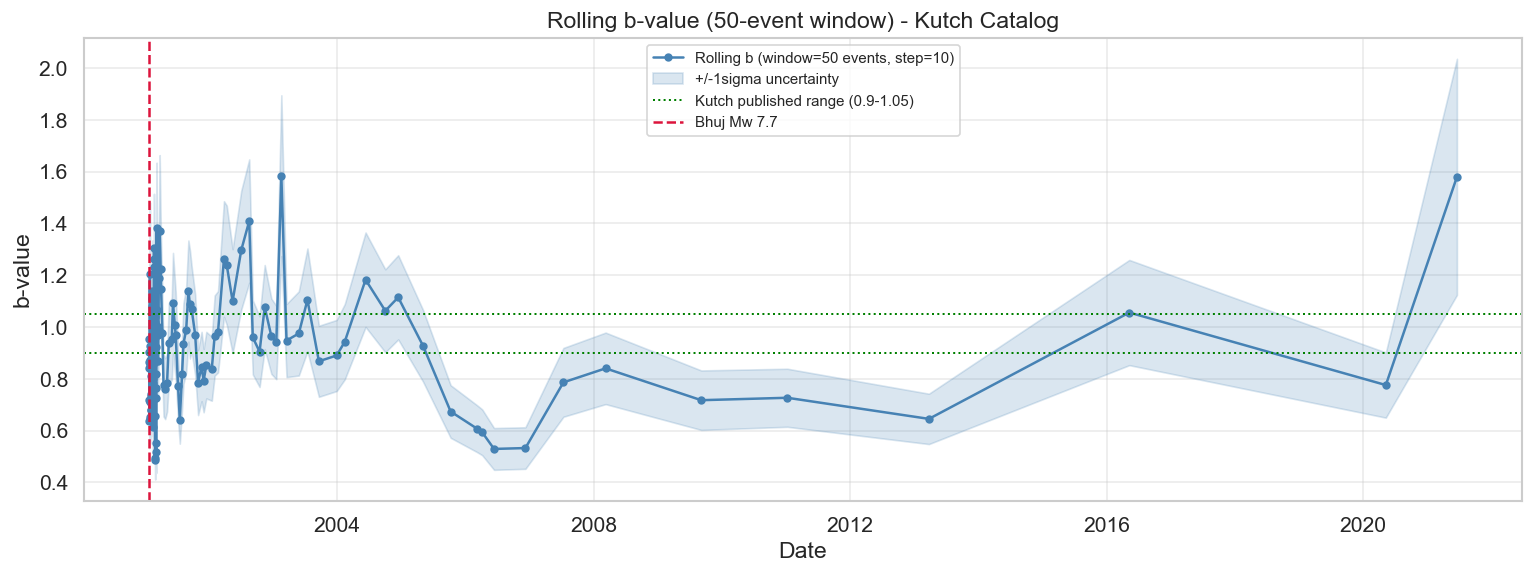

Saved -> outputs/rolling_bvalue.png


In [18]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(roll_t, roll_b, 'o-', color='steelblue', linewidth=1.5,
        markersize=4, label=f'Rolling b (window={WINDOW} events, step={STEP})')
ax.fill_between(roll_t, roll_b - roll_sb, roll_b + roll_sb,
                color='steelblue', alpha=0.2, label='+/-1sigma uncertainty')

ax.axhline(0.9,  color='green', linestyle=':', linewidth=1.2,
           label='Kutch published range (0.9-1.05)')
ax.axhline(1.05, color='green', linestyle=':', linewidth=1.2)
ax.axvline(np.datetime64('2001-01-26'), color='crimson', linestyle='--',
           linewidth=1.5, label='Bhuj Mw 7.7')

ax.set_xlabel('Date')
ax.set_ylabel('b-value')
ax.set_title(f'Rolling b-value (50-event window) - Kutch Catalog')
ax.legend(fontsize=9)
ax.grid(alpha=0.4)

fig.tight_layout()
fig.savefig(OUT_DIR / 'rolling_bvalue.png')
plt.show()
print('Saved -> outputs/rolling_bvalue.png')

---
## 9  Omori-Utsu Verification: log(time) vs log(rate)

The log-log Omori plot is the standard visual confirmation of power-law decay.
A straight line confirms Omori-Utsu behavior (slope = -p).

Deviations reveal:
- **Early kink**: detection incompleteness (day 0 excluded)
- **Late flattening**: background seismicity re-emerging
- **Step change**: secondary sequences from large aftershocks

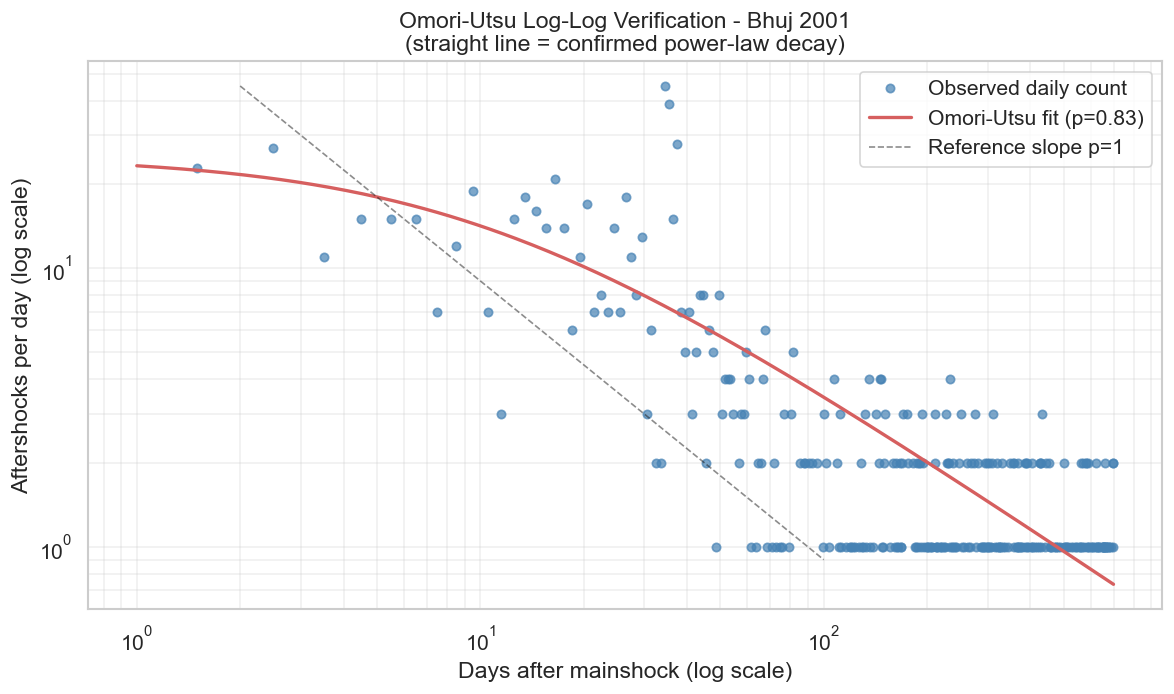

Saved -> outputs/omori_loglog_verification.png


In [19]:
fig, ax = plt.subplots(figsize=(10, 6))

nz_ll = daily_counts > 0
ax.loglog(day_centers[nz_ll], daily_counts[nz_ll], 'o', color='steelblue',
          markersize=5, alpha=0.7, label='Observed daily count')

if fit_ok:
    t_smooth_ll = np.logspace(0, np.log10(max_day), 300)
    ax.loglog(t_smooth_ll, omori_utsu(t_smooth_ll, *popt), 'r-', linewidth=2,
              label=f'Omori-Utsu fit (p={p_fit:.2f})')
    # Reference slope for p=1
    t_ref = np.array([2.0, 100.0])
    rate_ref = omori_utsu(5, *popt) * (5 / t_ref) ** 1.0
    ax.loglog(t_ref, rate_ref, 'k--', linewidth=1, alpha=0.5, label='Reference slope p=1')

ax.set_xlabel('Days after mainshock (log scale)')
ax.set_ylabel('Aftershocks per day (log scale)')
ax.set_title('Omori-Utsu Log-Log Verification - Bhuj 2001\n'
             '(straight line = confirmed power-law decay)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_DIR / 'omori_loglog_verification.png')
plt.show()
print('Saved -> outputs/omori_loglog_verification.png')

---
## Summary

| Metric | Reference |
|--------|-----------|
| Total events | see §1 |
| Date range | see §1 |
| Mc (MAXC) | see §6b |
| Mc (GFT 90%) | see §6b |
| b-value (MLE, GFT Mc) | see §6b |
| Omori p-value | see §7 |
| Rolling b range | see §8 |

**Outputs in `outputs/`**:
- `magnitude_distribution.png`
- `depth_distribution.png`
- `temporal_trends.png`
- `spatial_map.png`
- `gutenberg_richter.png` (MAXC Mc)
- `gutenberg_richter_dual_mc.png` (MAXC vs GFT comparison)
- `omori_utsu_decay.png`
- `rolling_bvalue.png`
- `omori_loglog_verification.png`
- `kutch_interactive_map.html`